In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_excel(r"D:\my project\codeit_datascience\data_science\regression\data science\Ecommerce Sales Data.xlsx")

In [4]:
data.head(2)


,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


# removing outliers

<Axes: ylabel='Sales'>

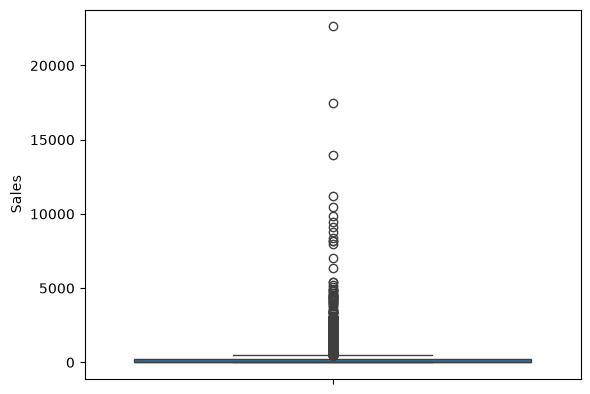

In [6]:
# outlier: unusual data they are not errors
sns.boxplot(y='Sales', data=data)

In [7]:
# find and replace outliers
# IQR, Zscore, mean & std method


# Remove outliers in Sales column

Text(0.5, 1.0, 'KDE plot of Sales')

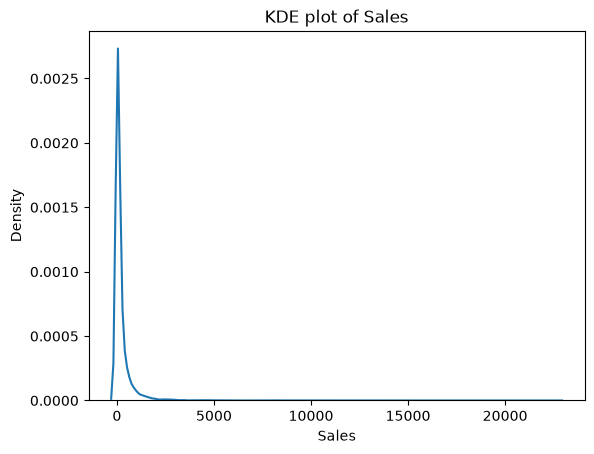

In [9]:
sns.kdeplot(x='Sales', data=data)
plt.title("KDE plot of Sales")

In [10]:
# REmove outlier using IQR
# q1 -- first quaratile
# q3 --third quartile
# iqr (inter quartile range)
# lower bound
# uperbound



In [11]:
q1 = data['Sales'].quantile(0.25)
print("first quartile:",q1)

first quartile: 17.28


In [12]:
q3 = data['Sales'].quantile(0.75)
print("third quartile:", q3)

third quartile: 209.94


In [13]:
iqr = q3 - q1
print(" IQR:", iqr)

 IQR: 192.66


In [14]:
lb = q1 - 1.5 * iqr
print("Lower limit: ",lb)

Lower limit:  -271.71000000000004


In [15]:
ub= q3 + 1.5 * iqr
print("Upper limit: ", ub)

Upper limit:  498.93


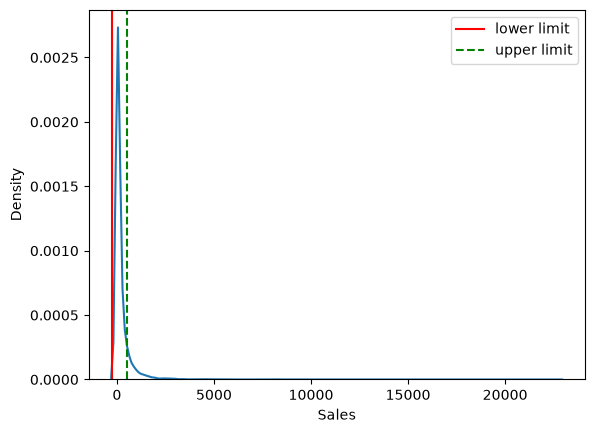

In [23]:
sns.kdeplot(x='Sales', data=data)
plt.axvline(lb, linestyle='-', color='red', label='lower limit')
plt.axvline(ub, linestyle='--',color='green', label='upper limit')
plt.legend()
plt.show()

In [30]:
# Remove outliers
con1 = data['Sales']>=lb
con2 = data['Sales']<=ub



In [31]:
data[con1 & con2]

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
5,6,CA-2011-115812,2011,2011-09-06 00:00:00,6/14/2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2011-115812,2011,2011-09-06 00:00:00,6/14/2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,1/22/2011,1/24/2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200


In [32]:
data.shape

(9994, 22)

In [33]:
df_iqr= data[con1 & con2]
df_iqr.head()

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
5,6,CA-2011-115812,2011,2011-09-06 00:00:00,6/14/2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2011-115812,2011,2011-09-06 00:00:00,6/14/2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


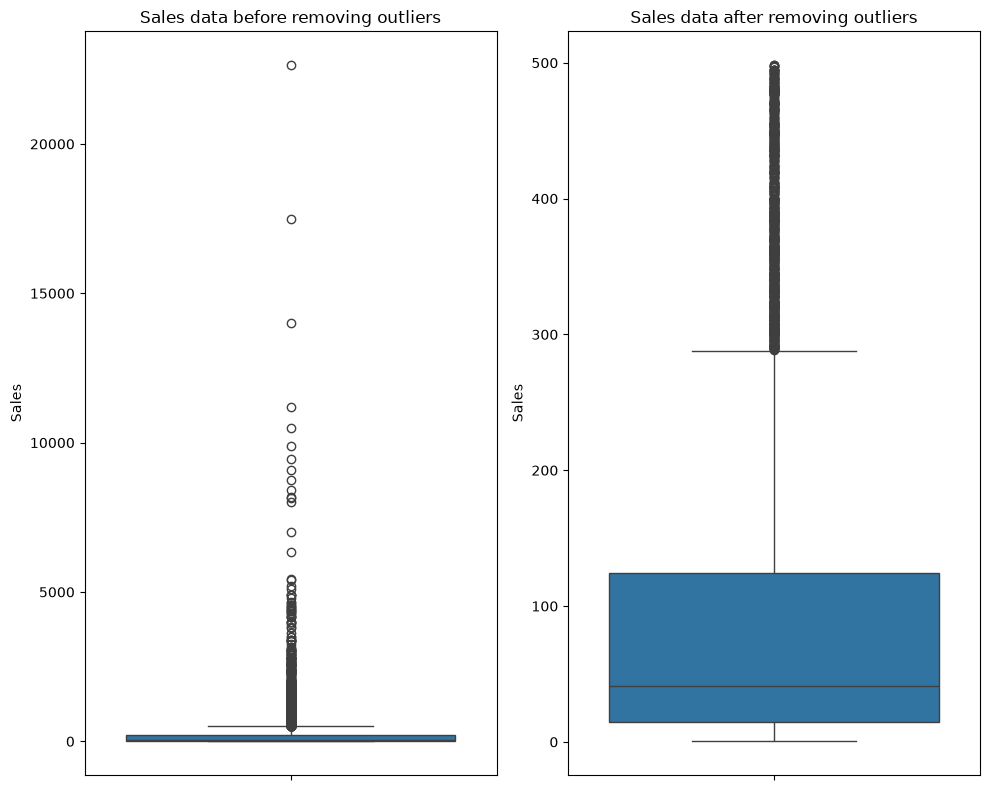

In [39]:
# plt the 'sales'
fig, axes = plt.subplots(1,2,figsize=(10,8))
sns.boxplot(y='Sales',data=data, ax=axes[0])
axes[0].set_title("Sales data before removing outliers")
sns.boxplot(y='Sales', data=df_iqr, ax=axes[1])
axes[1].set_title("Sales data after removing outliers")
plt.tight_layout()
plt.show()

# Zscore method

In [40]:
from scipy import stats

ModuleNotFoundError: No module named 'scipy'

In [43]:
!pip install scipy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
from scipy import stats

In [45]:
data['zscore'] = stats.zscore(data.Sales)

In [46]:
data.head(2)

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,0.051510
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,0.805633


In [47]:
# values between 3 to -3 
data['zscore'] = abs(data['zscore'])

In [48]:
data

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.051510
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.805633
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.345368
3,4,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.167688
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.332935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,1/22/2011,1/24/2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.328314
9990,9991,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.221269
9991,9992,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.046080
9992,9993,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.321331


In [49]:
data.zscore.agg(['min','max'])

min     0.000132
max    35.956549
Name: zscore, dtype: float64

In [50]:
data[data['zscore']<=3]

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.051510
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.805633
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.345368
3,4,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.167688
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.332935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,1/22/2011,1/24/2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.328314
9990,9991,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.221269
9991,9992,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.046080
9992,9993,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.321331


In [51]:
df_zscore = data[data['zscore']<=3]

In [52]:
df_zscore.shape

(9867, 23)

In [53]:
df_zscore['zscore'].agg(['min','max'])

min    0.000132
max    2.967748
Name: zscore, dtype: float64

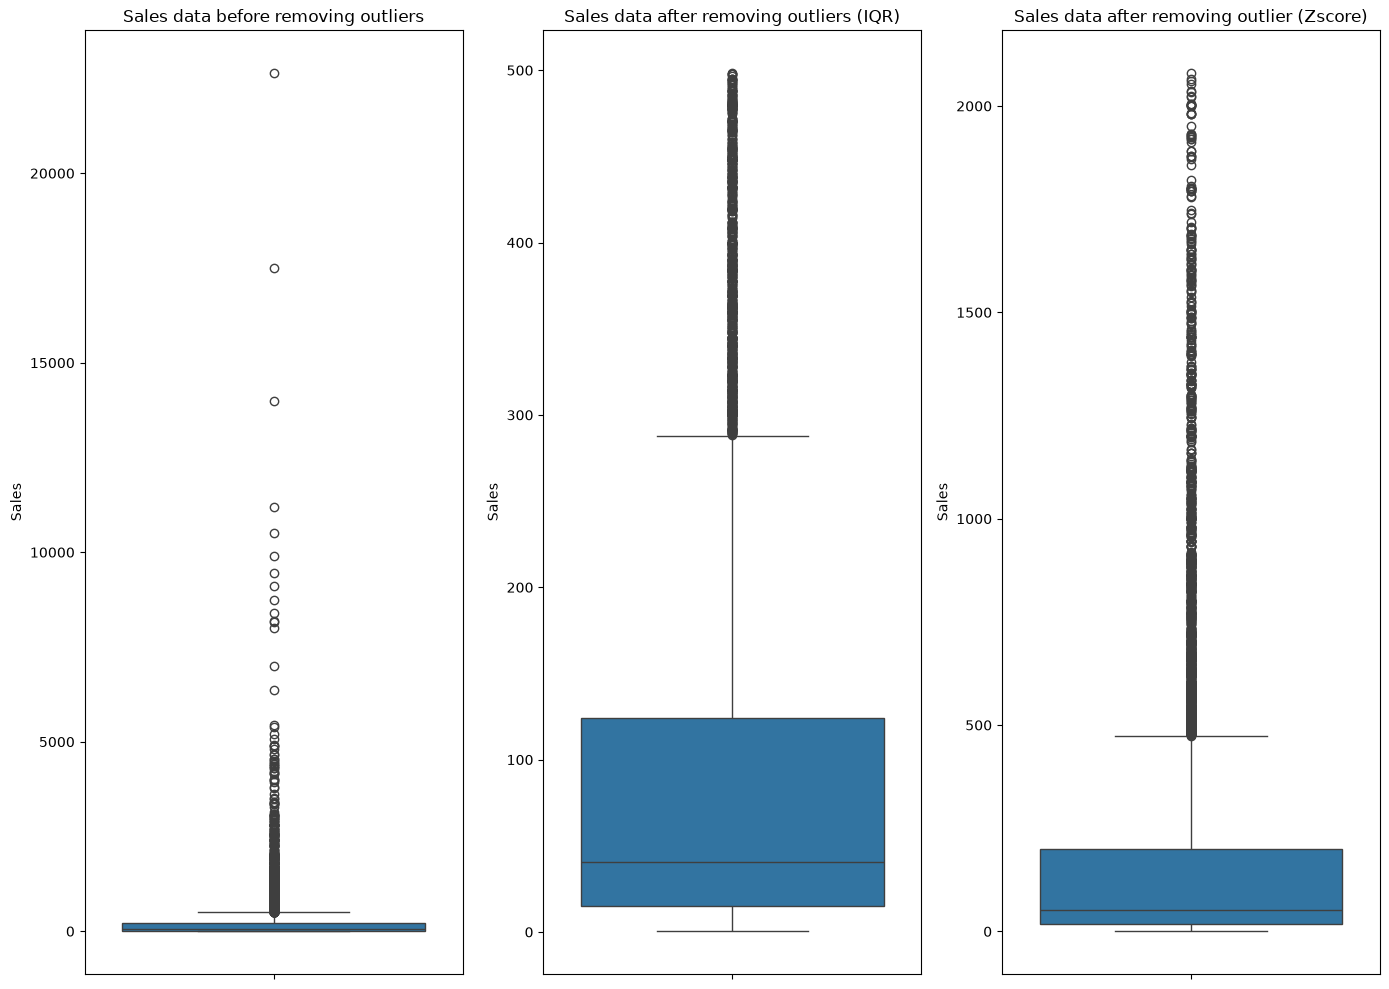

In [55]:
# plt the 'sales'
fig, axes = plt.subplots(1,3,figsize=(14,10))
sns.boxplot(y='Sales',data=data, ax=axes[0])
axes[0].set_title("Sales data before removing outliers")
sns.boxplot(y='Sales', data=df_iqr, ax=axes[1])
axes[1].set_title("Sales data after removing outliers (IQR)")
sns.boxplot(y='Sales', data=df_zscore, ax=axes[2])
axes[2].set_title("Sales data after removing outlier (Zscore)")
plt.tight_layout()
plt.show()

In [56]:
# std and mean method
std = data['Sales'].std()
std

np.float64(623.2451005086808)

In [57]:
m = data['Sales'].mean()
m

np.float64(229.85800083049827)

In [58]:
lower_bound = m -3 * std
lower_bound

np.float64(-1639.8773006955441)

In [59]:
upper_bound = m + 3 * std
upper_bound

np.float64(2099.593302356541)

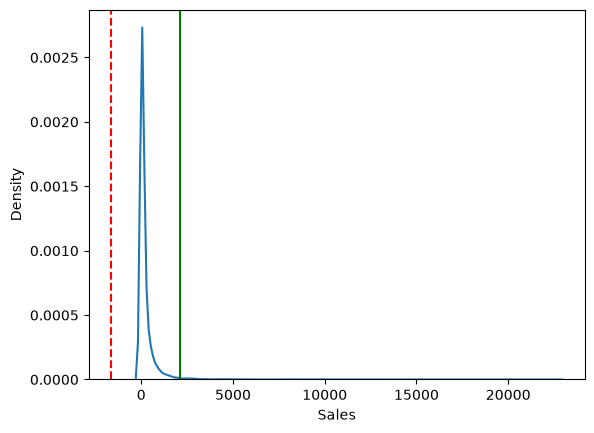

In [62]:
sns.kdeplot(x='Sales', data=data)
plt.axvline(lower_bound, linestyle='--', color='red')
plt.axvline(upper_bound, linestyle='-', color='green')

In [63]:
c1 = data.Sales <= upper_bound
c2 = data.Sales >= lower_bound
data[c1 & c2]

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.051510
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.805633
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.345368
3,4,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.167688
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.332935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,1/22/2011,1/24/2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.328314
9990,9991,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.221269
9991,9992,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.046080
9992,9993,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.321331


In [64]:
df_std_mean = data[c1 & c2]
df_std_mean

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.051510
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.805633
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.345368
3,4,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.167688
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.332935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,1/22/2011,1/24/2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.328314
9990,9991,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.221269
9991,9992,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.046080
9992,9993,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.321331


In [65]:
# std and mean
# original data set
std_o = data.Sales.std()
mean_o = data.Sales.mean()
print(f"Original data, mean: {mean_o}, std: {std_o}")

Original data, mean: 229.85800083049827, std: 623.2451005086808


In [67]:
# data set after using std and mean method
std_a = df_std_mean.Sales.std()
mean_a = df_std_mean.Sales.mean()
print(f"df_std_mean dataset, mean: {mean_a}, std: {std_a}")

df_std_mean dataset, mean: 180.55823053613054, std: 304.1508175033771


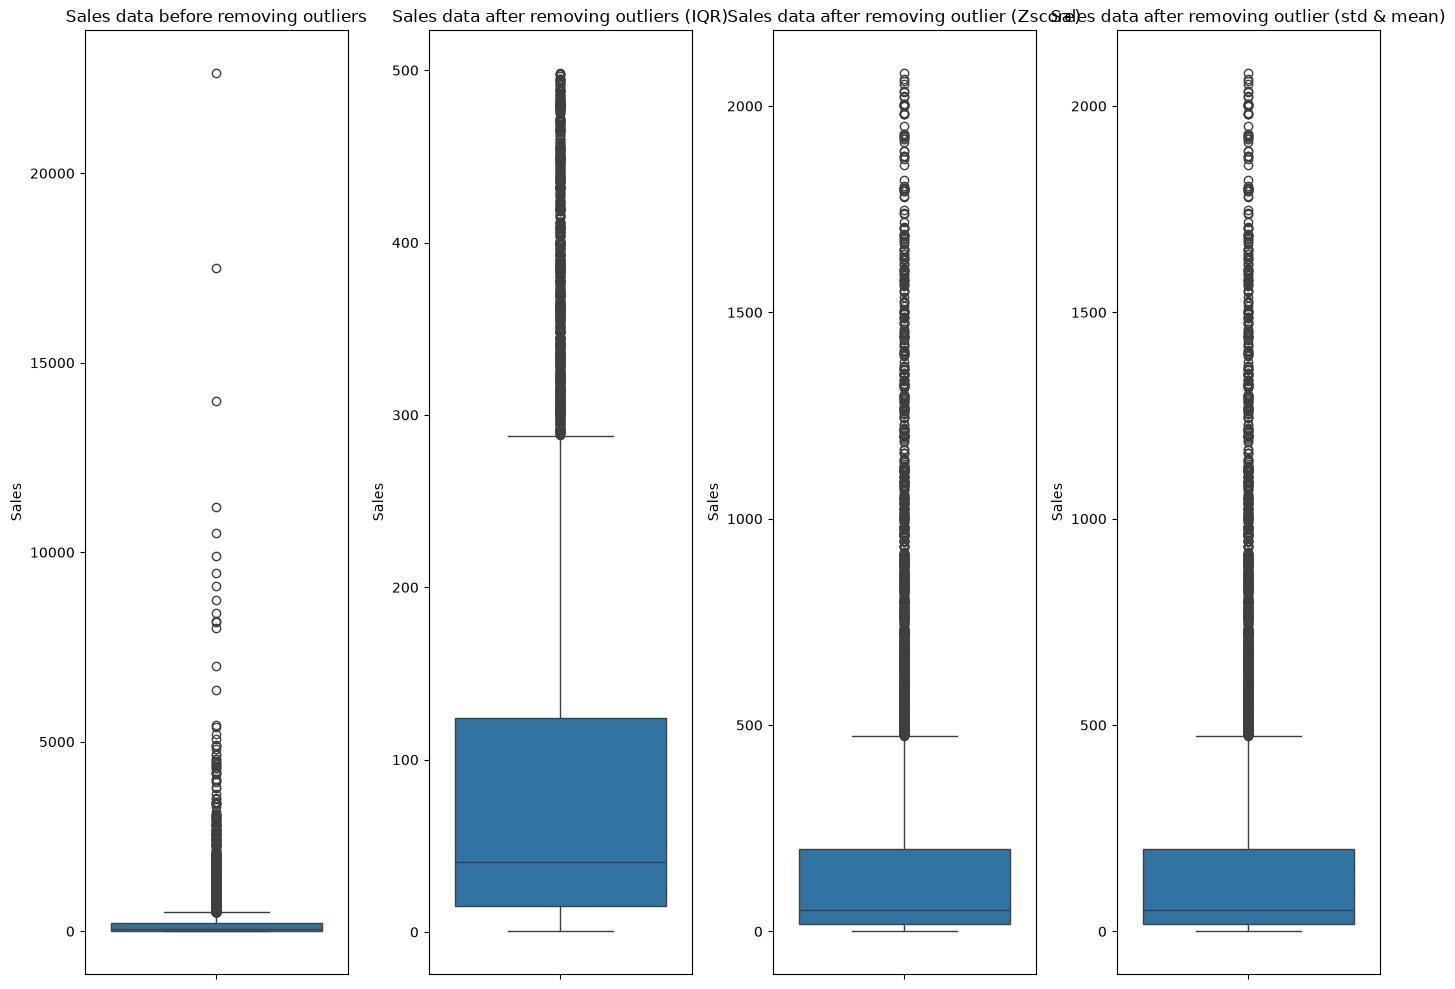

In [68]:
# plt the 'sales'
fig, axes = plt.subplots(1,4,figsize=(14,10))
sns.boxplot(y='Sales',data=data, ax=axes[0])
axes[0].set_title("Sales data before removing outliers")
sns.boxplot(y='Sales', data=df_iqr, ax=axes[1])
axes[1].set_title("Sales data after removing outliers (IQR)")
sns.boxplot(y='Sales', data=df_zscore, ax=axes[2])
axes[2].set_title("Sales data after removing outlier (Zscore)")
sns.boxplot(y='Sales', data=df_std_mean, ax=axes[3])
axes[3].set_title("Sales data after removing outlier (std & mean)")
plt.tight_layout()
plt.show()

In [70]:
# Get skew() value
skew_all = data['Sales'].skew()
skew_iqr = df_iqr.Sales.skew()
skew_zscore = df_zscore.Sales.skew()
skew_std_mean = df_std_mean.Sales.skew()

In [71]:
print(f"Skew of all data: {skew_all}")
print(f"Skew of data with IQR: {skew_iqr}")
print(f"Skew of data with Zscore: {skew_zscore}")
print(f"Skew of data with std mean: {skew_std_mean}")

Skew of all data: 12.97275234181623
Skew of data with IQR: 1.6850350102197391
Skew of data with Zscore: 2.9658834264117755
Skew of data with std mean: 2.9658834264117755


In [72]:
# based on skew() if skew value is near to zero is consider best data
# based on the above skew value, we conclude that IQR method removed the outlier better than other method
# Amond all the given skew value, skew with IQR method is less, so dataset 'df_iqr' will be considered as data without outliers


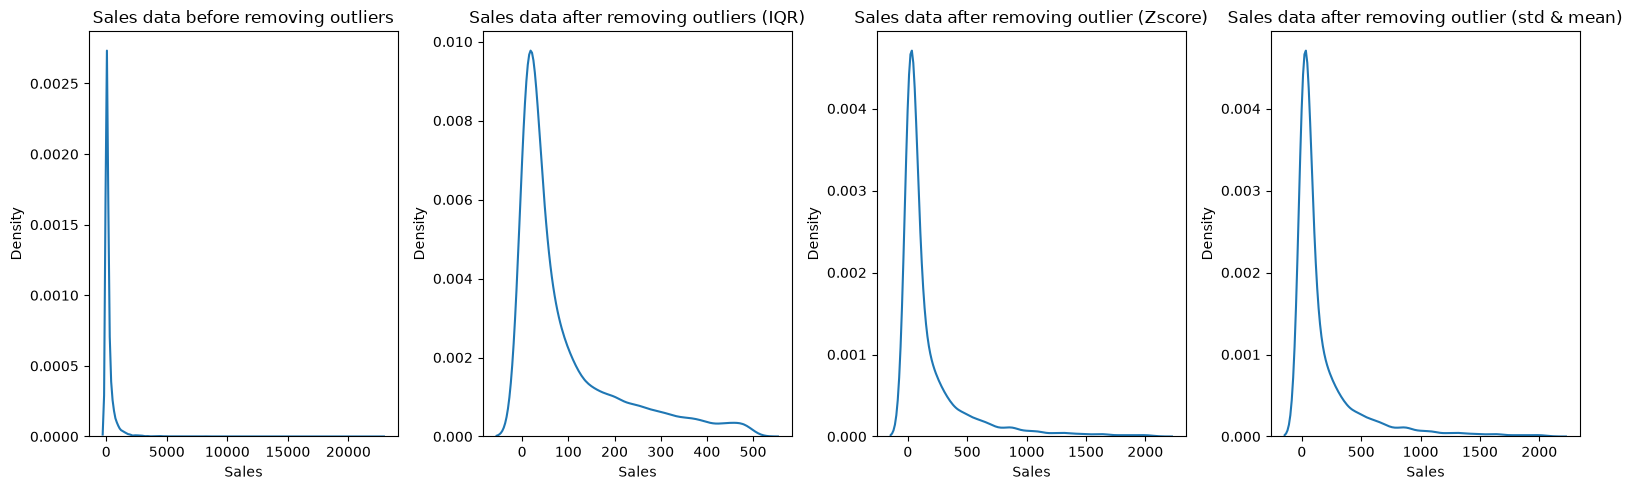

In [76]:
# Visual Inspection with KDE plot
fig, axes = plt.subplots(1,4,figsize=(16,5))
sns.kdeplot(x='Sales',data=data, ax=axes[0])
axes[0].set_title("Sales data before removing outliers")
sns.kdeplot(x='Sales', data=df_iqr, ax=axes[1])
axes[1].set_title("Sales data after removing outliers (IQR)")
sns.kdeplot(x='Sales', data=df_zscore, ax=axes[2])
axes[2].set_title("Sales data after removing outlier (Zscore)")
sns.kdeplot(x='Sales', data=df_std_mean, ax=axes[3])
axes[3].set_title("Sales data after removing outlier (std & mean)")
plt.tight_layout()
plt.show()

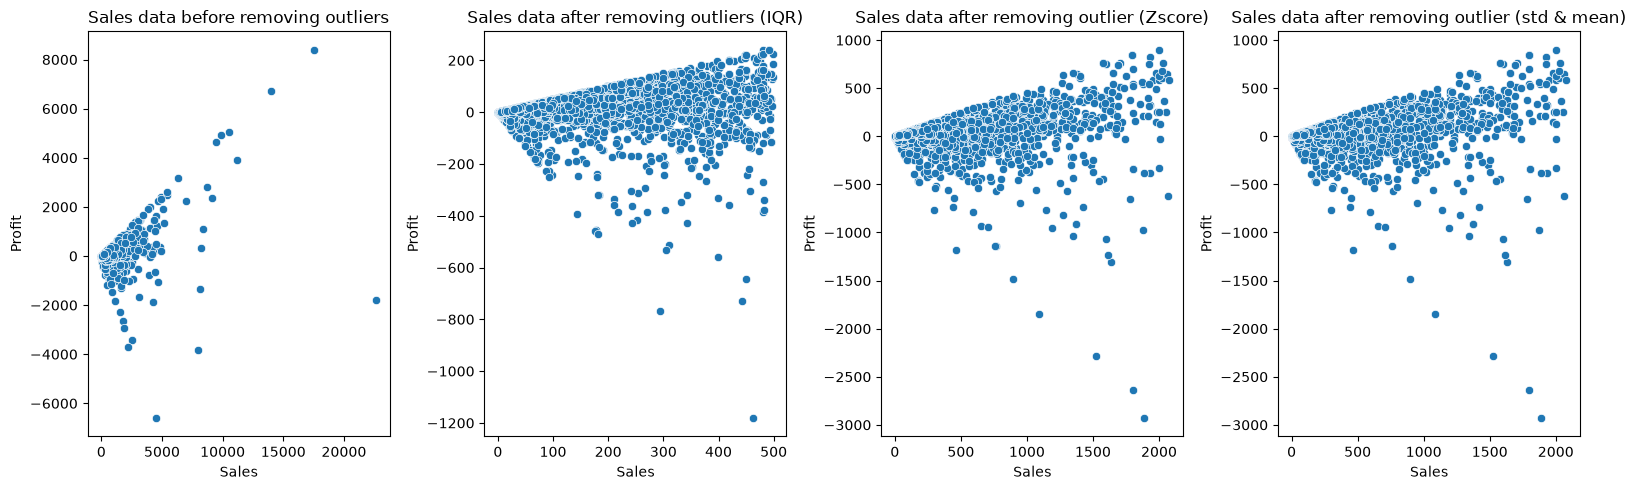

In [79]:
# Scatter plot
fig, axes = plt.subplots(1,4,figsize=(16,5))
sns.scatterplot(x='Sales',y='Profit', data=data, ax=axes[0])
axes[0].set_title("Sales data before removing outliers")
sns.scatterplot(x='Sales',y='Profit', data=df_iqr, ax=axes[1])
axes[1].set_title("Sales data after removing outliers (IQR)")
sns.scatterplot(x='Sales',y='Profit', data=df_zscore, ax=axes[2])
axes[2].set_title("Sales data after removing outlier (Zscore)")
sns.scatterplot(x='Sales',y='Profit', data=df_std_mean, ax=axes[3])
axes[3].set_title("Sales data after removing outlier (std & mean)")
plt.tight_layout()
plt.show()